In [54]:
%matplotlib inline
import os
import numpy as np
from typing import _TypedDict, Dict
import yaml

import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from tampanda import ArmSceneBuilder, RRTStar, GraspPlanner, PickPlaceExecutor
from tampanda.scenes import TABLE_SYMBOLIC_TEMPLATE, BLOCK_SMALL_TEMPLATE
from tampanda.tamp import DomainBridge
from tampanda.symbolic.domains.blocks.blocks_domain import BlocksDomain
from tampanda.planners.grasp_planner import GraspType, GRASP_CONTACT_OFFSET


In [55]:
import os
if "DISPLAY" in os.environ:
    del os.environ["DISPLAY"]
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":3"

In [56]:
# ── Visualisation helpers (provided) ──────────────────────────────────────────
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam
def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img
def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)
def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()
def _table_center():
    try: return ((BOUNDS["min_x"]+BOUNDS["max_x"])/2, (BOUNDS["min_y"]+BOUNDS["max_y"])/2, BOUNDS["table_height"])
    except NameError: return (0.4, 0.4, 0.27)
def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25):
    _show(_render(env, _free_cam(env, _table_center(), distance, azimuth, elevation)), title)
def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center(), distance, 90, -89)), title)
def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)
def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")
print("Visualisation helpers ready ✓")

Visualisation helpers ready ✓


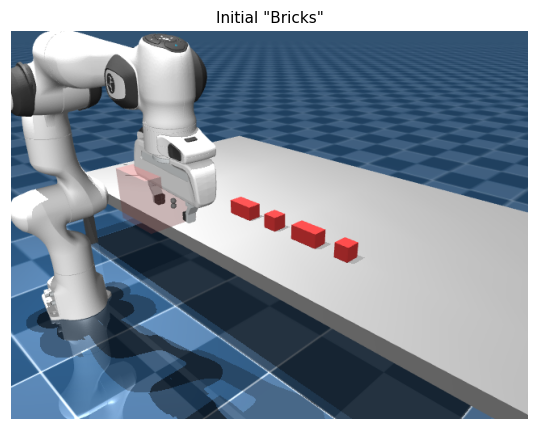

In [58]:

with open('dataset/benchmark_tasks/tier2/task_063.yaml', 'r') as file:
    yaml_content = file.read()


product_data = yaml.safe_load(yaml_content)
blocks_info = product_data.get('blocks', [])

builder = ArmSceneBuilder()
builder.add_resource("table", TABLE_SYMBOLIC_TEMPLATE)
#TODO: Check workbenchmark Tier 1 and 2 regarding other potential block types
builder.add_resource("block_2x2", "block_templates/brick_2x2.xml") 
builder.add_resource("block_4x2", "block_templates/brick_4x2.xml") 

builder.add_object("table", name="table", pos=[0.0, 0.4, 0.0], quat=[0.0, 0.0, 0.0, 1.0])

# Line up blocks along the x axis
START_X = 0.30
START_Y = 0.40
SPACING = 0.12
Z_DROP = 0.10 

for i, brick in enumerate(blocks_info):
    block_name = brick['name']
    if brick['type'] == 'brick_2x2':
        builder_name = "block_2x2"
    elif brick['type'] == 'brick_4x2':
        builder_name = "block_4x2"
    else:
        builder_name = "block_2x2"
        print("Warning: Block type not known!")

    init_pos = [START_X + (i * SPACING), START_Y, Z_DROP]
    builder.add_object(builder_name, name=block_name, pos=init_pos, quat=[1.0, 0.0, 0.0, 0.0])

env = builder.build_env(rate=200.0)

domain = BlocksDomain(env.model, table_geom_name="table_surface")
BOUNDS = domain.get_working_bounds()
TABLE_Z = BOUNDS["table_height"]
    
if len(blocks_info) > 0:
    first_block_name = blocks_info[0]['name']
    BLOCK_HALF = env.get_object_half_size(first_block_name)
    
    for i, brick in enumerate(blocks_info):
        block_name = brick['name']
        init_x = START_X + (i * SPACING)
        init_y = START_Y
        init_z = TABLE_Z + BLOCK_HALF[2] + 0.003
        
        env.set_object_pose(block_name, np.array([init_x, init_y, init_z]))

env.reset_velocities()
env.forward()
env.rest(0.4)


# Show the resulting lined-up blocks
show_scene(env, "Initial \"Bricks\"")